In [41]:
# ===== CELL 1: Import Libraries =====

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [43]:
# ===== CELL 2: Load and Explore Data =====

In [44]:
# Load the dataset
df = pd.read_csv("amazon-fine-food-reviews/Reviews.csv")

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nColumn names and types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

Dataset shape: (568454, 10)

First few rows:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bo

In [45]:
# ===== CELL 3: Data Cleaning =====

In [46]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any
df = df.drop_duplicates()

# Handle missing values
print(f"\nMissing values after cleaning:")
print(df.isnull().sum())

# For this analysis, we'll focus on: Score, Text, Time
# Let's keep only rows with non-null Text and Score
df = df[df['Text'].notna() & df['Score'].notna()]

print(f"\nDataset shape after cleaning: {df.shape}")

Duplicate rows: 0

Missing values after cleaning:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Dataset shape after cleaning: (568454, 10)


In [47]:
# ===== CELL 4: Rating Distribution =====

Score value counts:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


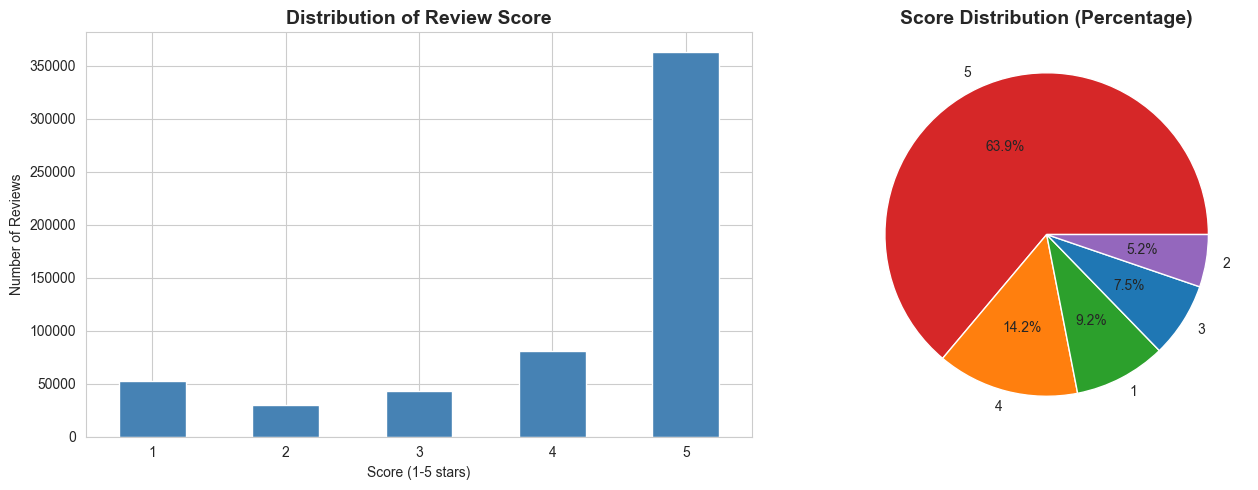


📊 Key insight: 363122 reviews are 5-star (63.9%)
   Only 52268 reviews are 1-star (9.2%)


In [48]:
print("Score value counts:")
print(df['Score'].value_counts().sort_index())

# Visualize rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
df['Score'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Review Score', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score (1-5 stars)')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['Score'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd'])
axes[1].set_title('Score Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\n📊 Key insight: {df['Score'].value_counts()[5]} reviews are 5-star ({(df['Score'].value_counts()[5]/len(df)*100):.1f}%)")
print(f"   Only {df['Score'].value_counts()[1]} reviews are 1-star ({(df['Score'].value_counts()[1]/len(df)*100):.1f}%)")

In [49]:
# ===== CELL 5: Review Length Analysis =====

Review length statistics (characters):
count    568454.000000
mean        436.222083
std         445.339741
min          12.000000
25%         179.000000
50%         302.000000
75%         527.000000
max       21409.000000
Name: review_length, dtype: float64

Word count statistics:
count    568454.000000
mean         80.264023
std          79.455384
min           3.000000
25%          33.000000
50%          56.000000
75%          98.000000
max        3432.000000
Name: word_count, dtype: float64


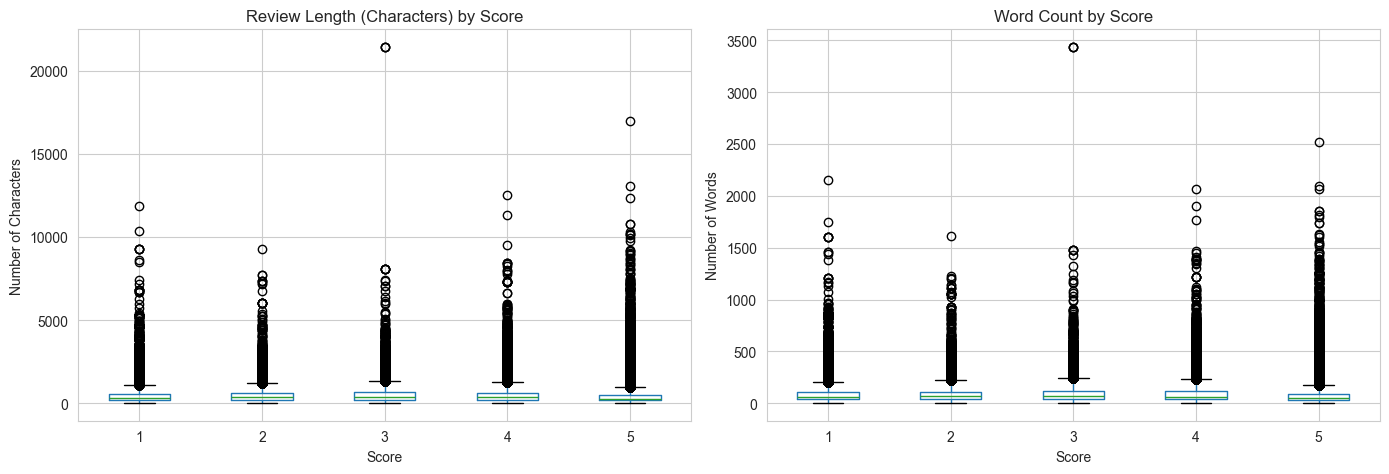


📊 Key insight: 5-star reviews average 74 words
   1-star reviews average 87 words


In [50]:
# Calculate text length
df['review_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

print("Review length statistics (characters):")
print(df['review_length'].describe())

print("\nWord count statistics:")
print(df['word_count'].describe())

# Visualize review length by rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: review length by rating
df.boxplot(column='review_length', by='Score', ax=axes[0])
axes[0].set_title('Review Length (Characters) by Score')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of Characters')

# Box plot: word count by rating
df.boxplot(column='word_count', by='Score', ax=axes[1])
axes[1].set_title('Word Count by Score')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Number of Words')

plt.suptitle('')  # Remove the automatic title
plt.tight_layout()
plt.show()

print(f"\n📊 Key insight: 5-star reviews average {df[df['Score']==5]['word_count'].mean():.0f} words")
print(f"   1-star reviews average {df[df['Score']==1]['word_count'].mean():.0f} words")

In [51]:
# ===== CELL 6: Time-based Analysis =====

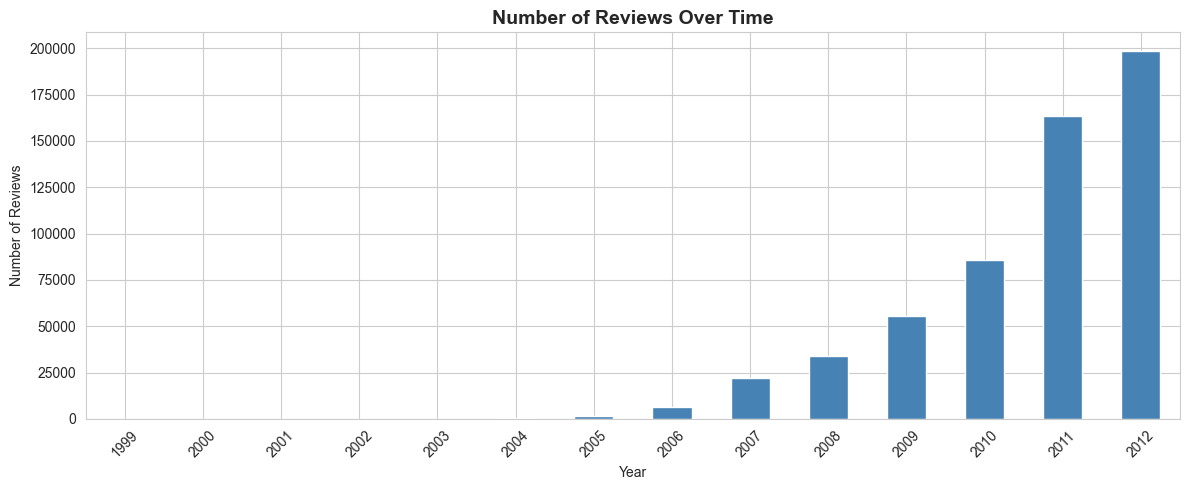

Reviews per year:
Year
1999         6
2000        32
2001        13
2002        73
2003       132
2004       561
2005      1335
2006      6671
2007     22300
2008     34163
2009     55326
2010     85884
2011    163299
2012    198659
Name: count, dtype: int64


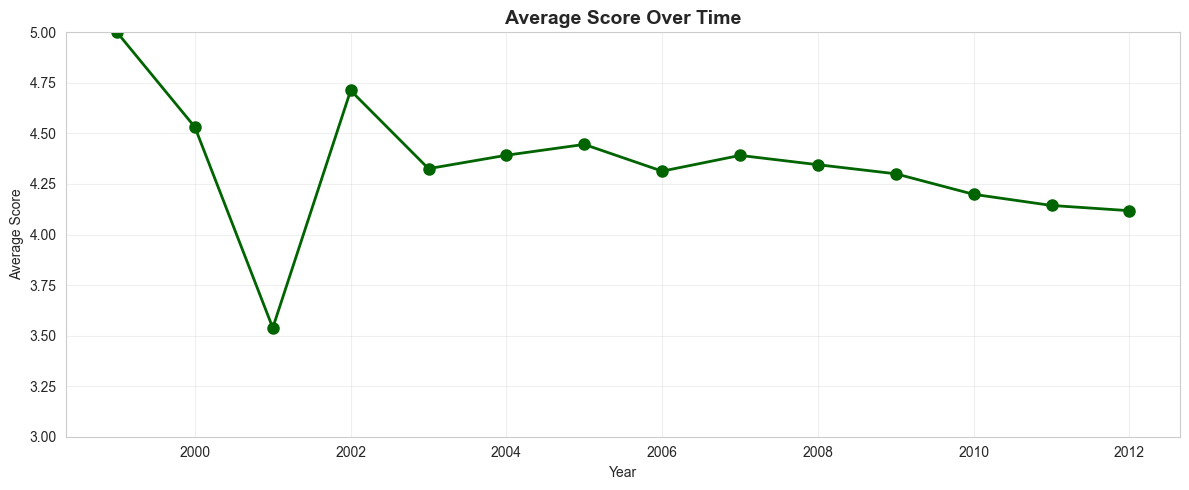


Average score by year:
Year
1999    5.000000
2000    4.531250
2001    3.538462
2002    4.712329
2003    4.325758
2004    4.392157
2005    4.445693
2006    4.313446
2007    4.391345
2008    4.345344
2009    4.300365
2010    4.198838
2011    4.143804
2012    4.117885
Name: Score, dtype: float64


In [52]:
# Convert Time to datetime
df['Time'] = pd.to_datetime(df['Time'], unit='s')
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month

# Reviews per year
reviews_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
reviews_per_year.plot(kind='bar', color='steelblue')
plt.title('Number of Reviews Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Reviews per year:")
print(reviews_per_year)

# Average score over time
avg_score_by_year = df.groupby('Year')['Score'].mean()

plt.figure(figsize=(12, 5))
avg_score_by_year.plot(kind='line', marker='o', color='darkgreen', linewidth=2, markersize=8)
plt.title('Average Score Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.ylim(3, 5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAverage score by year:")
print(avg_score_by_year)

In [53]:
# ===== CELL 7: Product Analysis =====

In [54]:
# Top products reviewed
print("Top 10 most reviewed products:")
print(df['ProductId'].value_counts().head(10))

# Average score by product
product_stats = df.groupby('ProductId').agg({
    'Score': ['mean', 'count']
}).round(2)

product_stats.columns = ['Avg_Score', 'Review_Count']
product_stats = product_stats[product_stats['Review_Count'] >= 10].sort_values('Avg_Score', ascending=False)

print("\nTop 10 highest-rated products (with at least 10 reviews):")
print(product_stats.head(10))

print("\nTop 10 lowest-rated products (with at least 10 reviews):")
print(product_stats.tail(10))

Top 10 most reviewed products:
ProductId
B007JFMH8M    913
B0026RQTGE    632
B002QWHJOU    632
B002QWP89S    632
B002QWP8H0    632
B003B3OOPA    623
B001EO5Q64    567
B000VK8AVK    564
B0026KNQSA    564
B007M83302    564
Name: count, dtype: int64

Top 10 highest-rated products (with at least 10 reviews):
            Avg_Score  Review_Count
ProductId                          
B007BTN97Y        5.0            12
B005EL6VOY        5.0            33
B000YK7V9O        5.0            20
B005BGE5PE        5.0            12
B001EO5QP0        5.0            10
B000KEJMRI        5.0            19
B001682OOA        5.0            14
B000YH8YG6        5.0            12
B002AUHAHY        5.0            10
B000KXZ8E0        5.0            24

Top 10 lowest-rated products (with at least 10 reviews):
            Avg_Score  Review_Count
ProductId                          
B002EAN3T4       1.52            25
B000H26J7E       1.52            23
B00545EXFY       1.40            10
B004H3N2LU       1.37   

In [55]:
# ===== CELL 8: Helpfulness Analysis =====

Helpfulness statistics:
count    568454.000000
mean          0.273433
std           0.317269
min           0.000000
25%           0.000000
50%           0.000000
75%           0.500000
max           1.500000
Name: Helpfulness_Ratio, dtype: float64


<Figure size 1200x500 with 0 Axes>

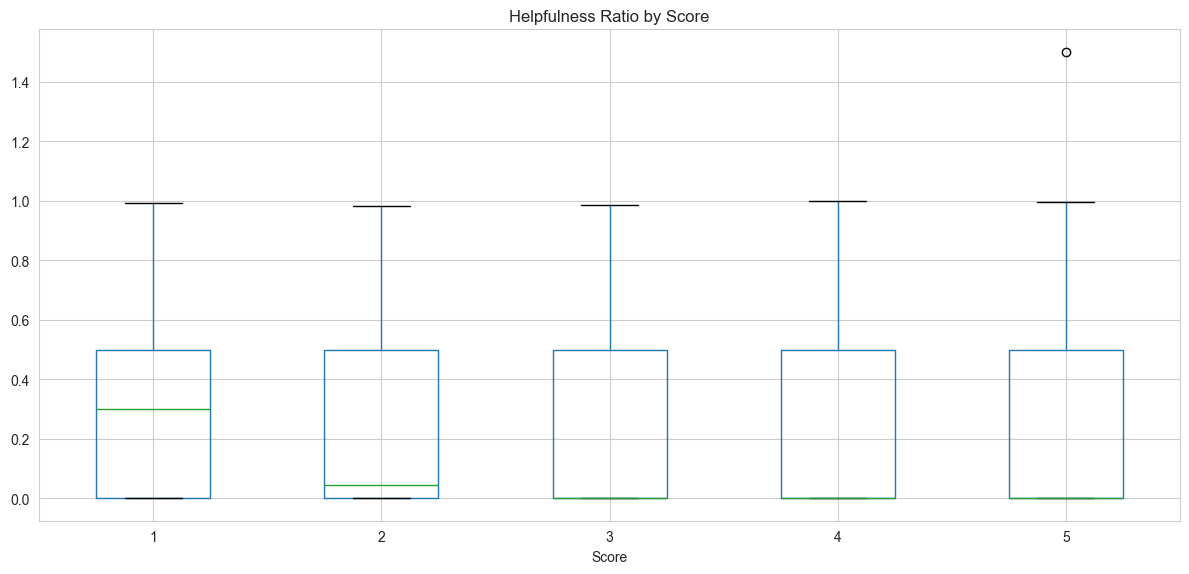

In [56]:
# If your data has Helpfulness columns
if 'HelpfulnessNumerator' in df.columns and 'HelpfulnessDenominator' in df.columns:
    # Calculate helpfulness ratio
    df['Helpfulness_Ratio'] = df['HelpfulnessNumerator'] / (df['HelpfulnessDenominator'] + 1)
    
    print("Helpfulness statistics:")
    print(df['Helpfulness_Ratio'].describe())
    
    # Helpfulness by score
    plt.figure(figsize=(12, 5))
    df.boxplot(column='Helpfulness_Ratio', by='Score')
    plt.title('Helpfulness Ratio by Score')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()
else:
    print("Helpfulness columns not found in dataset")

In [57]:
# ===== CELL 9: Text Preview =====

In [58]:
# Look at some actual reviews
print("\n=== SAMPLE 5-STAR REVIEW ===")
print(df[df['Score']==5]['Text'].iloc[0][:500])

print("\n=== SAMPLE 1-STAR REVIEW ===")
print(df[df['Score']==1]['Text'].iloc[0][:500])

print("\n=== SAMPLE 3-STAR REVIEW ===")
print(df[df['Score']==3]['Text'].iloc[0][:500])


=== SAMPLE 5-STAR REVIEW ===
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

=== SAMPLE 1-STAR REVIEW ===
Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

=== SAMPLE 3-STAR REVIEW ===
This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.


In [59]:
# ===== CELL 10: Summary Statistics =====

In [60]:
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*60)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total reviews: {len(df):,}")
print(f"   • Unique products: {df['ProductId'].nunique():,}")
print(f"   • Date range: {df['Time'].min().date()} to {df['Time'].max().date()}")
print(f"   • Average review length: {df['review_length'].mean():.0f} characters")

print(f"\n⭐ SCORE INSIGHTS:")
print(f"   • Most common score: {df['Score'].mode()[0]}-star ({(df['Score'].value_counts()[df['Score'].mode()[0]]/len(df)*100):.1f}%)")
print(f"   • Average score: {df['Score'].mean():.2f}/5.0")
print(f"   • Median score: {df['Score'].median():.1f}")

print(f"\n📝 TEXT INSIGHTS:")
print(f"   • Avg words per review: {df['word_count'].mean():.0f}")
print(f"   • Longest review: {df['review_length'].max():,} characters")
print(f"   • Shortest review: {df['review_length'].min()} characters")

print(f"\n⏰ TEMPORAL INSIGHTS:")
print(f"   • Peak review year: {reviews_per_year.idxmax()} with {reviews_per_year.max():,} reviews")
print(f"   • Score trend: {('Improving' if avg_score_by_year.iloc[-1] > avg_score_by_year.iloc[0] else 'Declining')}")

print("\n✓ EDA Complete! Ready for machine learning analysis.")


EXPLORATORY DATA ANALYSIS SUMMARY

📊 DATASET OVERVIEW:
   • Total reviews: 568,454
   • Unique products: 74,258
   • Date range: 1999-10-08 to 2012-10-26
   • Average review length: 436 characters

⭐ SCORE INSIGHTS:
   • Most common score: 5-star (63.9%)
   • Average score: 4.18/5.0
   • Median score: 5.0

📝 TEXT INSIGHTS:
   • Avg words per review: 80
   • Longest review: 21,409 characters
   • Shortest review: 12 characters

⏰ TEMPORAL INSIGHTS:
   • Peak review year: 2012 with 198,659 reviews
   • Score trend: Declining

✓ EDA Complete! Ready for machine learning analysis.


In [61]:
# ===== CELL 11: Prepare data for ML (Text preprocessing) =====

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Create binary classification: Positive (4-5 stars) vs Negative (1-2 stars)
# We'll ignore 3-star reviews as they're neutral
df_ml = df[(df['Score'] != 3)].copy()
df_ml['Sentiment'] = df_ml['Score'].apply(lambda x: 'Positive' if x >= 4 else 'Negative')

print(f"Dataset for ML: {len(df_ml)} reviews")
print(f"\nSentiment distribution:")
print(df_ml['Sentiment'].value_counts())

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    df_ml['Text'], 
    df_ml['Sentiment'], 
    test_size=0.2, 
    random_state=42,
    stratify=df_ml['Sentiment']
)

print(f"\nTrain set: {len(X_train)} reviews")
print(f"Test set: {len(X_test)} reviews")

# Vectorize text using TF-IDF (convert text to numbers)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"\n✓ Text vectorized: {X_train_tfidf.shape[1]} features created")

Dataset for ML: 525814 reviews

Sentiment distribution:
Sentiment
Positive    443777
Negative     82037
Name: count, dtype: int64

Train set: 420651 reviews
Test set: 105163 reviews

✓ Text vectorized: 5000 features created


In [63]:
# ===== CELL 12: Train Naive Bayes Model =====

Naive Bayes Accuracy: 0.8895 (88.95%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.33      0.48     16407
    Positive       0.89      0.99      0.94     88756

    accuracy                           0.89    105163
   macro avg       0.89      0.66      0.71    105163
weighted avg       0.89      0.89      0.87    105163



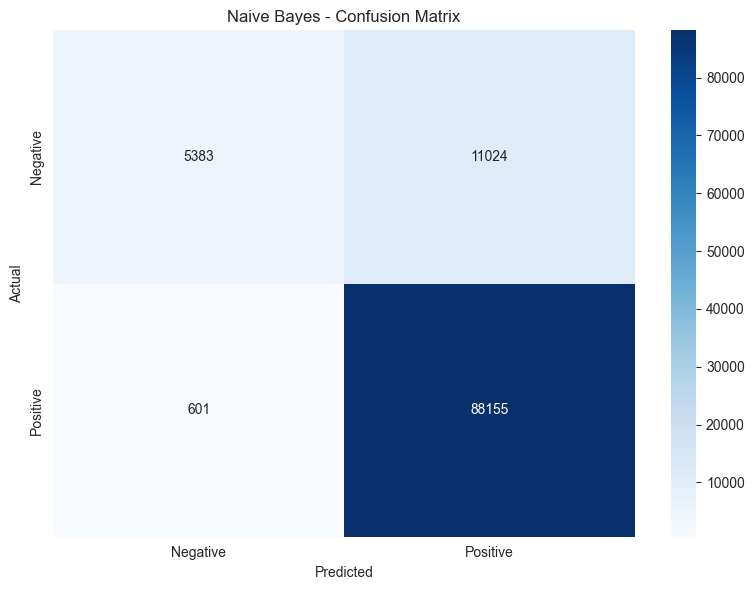

In [64]:
# Train Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test_tfidf)

# Accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Naive Bayes - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [65]:
# ===== CELL 13: Train Random Forest Model =====

Training Random Forest... (this may take a minute)

Random Forest Accuracy: 0.9385 (93.85%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.65      0.77     16407
    Positive       0.94      0.99      0.96     88756

    accuracy                           0.94    105163
   macro avg       0.94      0.82      0.87    105163
weighted avg       0.94      0.94      0.93    105163



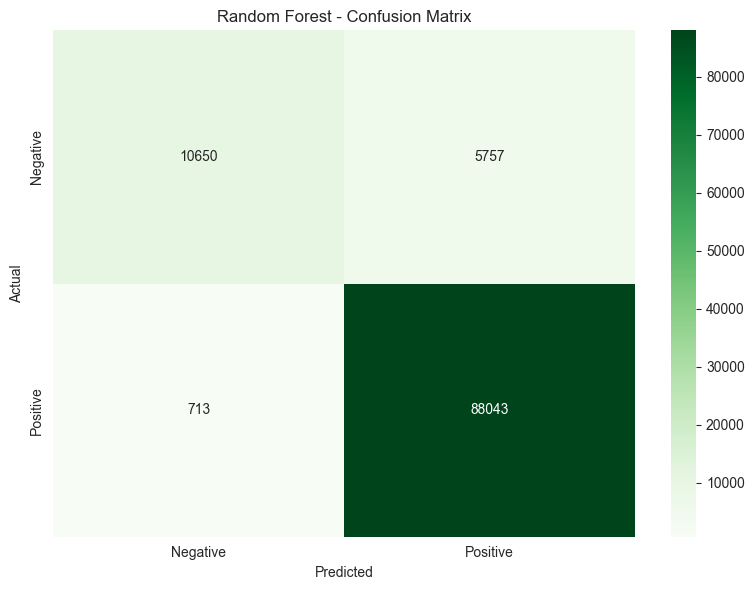

In [66]:
# Train Random Forest classifier (slower but often more accurate)
print("Training Random Forest... (this may take a minute)")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_tfidf)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
# ===== CELL 14: Model Comparison =====


MODEL COMPARISON
           Model  Accuracy
0    Naive Bayes  0.889457
1  Random Forest  0.938476


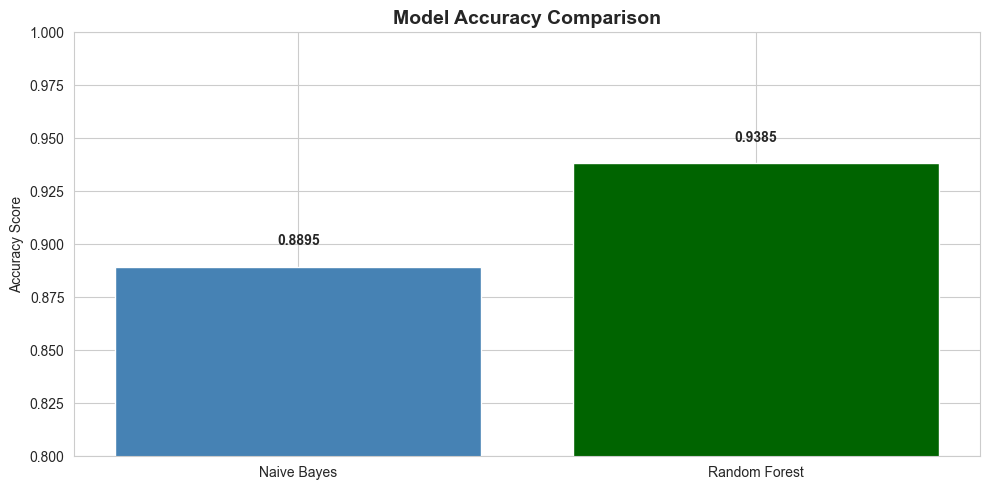


✓ Best Model: Random Forest
✓ Best Accuracy: 93.85%


In [67]:
# Compare models
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Random Forest'],
    'Accuracy': [accuracy_nb, accuracy_rf]
})

print(comparison)

# Visualize comparison
plt.figure(figsize=(10, 5))
plt.bar(comparison['Model'], comparison['Accuracy'], color=['steelblue', 'darkgreen'])
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score')
plt.ylim(0.8, 1.0)
for i, v in enumerate(comparison['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Choose best model
best_model = rf_model if accuracy_rf > accuracy_nb else nb_model
best_accuracy = max(accuracy_rf, accuracy_nb)
print(f"\n✓ Best Model: {'Random Forest' if accuracy_rf > accuracy_nb else 'Naive Bayes'}")
print(f"✓ Best Accuracy: {best_accuracy*100:.2f}%")

In [ ]:
# ===== CELL 15: Test on sample reviews =====

In [68]:
# Test the best model on sample reviews
sample_reviews = [
    "This product is amazing! Best purchase ever!",
    "Terrible quality, broke after one day.",
    "It's okay, nothing special but works fine.",
    "Absolutely love this! Highly recommend!",
    "Complete waste of money. Very disappointed."
]

sample_tfidf = vectorizer.transform(sample_reviews)
sample_predictions = best_model.predict(sample_tfidf)
sample_proba = best_model.predict_proba(sample_tfidf)

print("="*60)
print("SENTIMENT PREDICTIONS ON SAMPLE REVIEWS")
print("="*60)

for i, review in enumerate(sample_reviews):
    print(f"\nReview: {review}")
    print(f"Predicted Sentiment: {sample_predictions[i]}")
    print(f"Confidence: {max(sample_proba[i])*100:.2f}%")

SENTIMENT PREDICTIONS ON SAMPLE REVIEWS

Review: This product is amazing! Best purchase ever!
Predicted Sentiment: Positive
Confidence: 97.00%

Review: Terrible quality, broke after one day.
Predicted Sentiment: Negative
Confidence: 74.00%

Review: It's okay, nothing special but works fine.
Predicted Sentiment: Positive
Confidence: 59.00%

Review: Absolutely love this! Highly recommend!
Predicted Sentiment: Positive
Confidence: 87.00%

Review: Complete waste of money. Very disappointed.
Predicted Sentiment: Negative
Confidence: 94.00%


In [ ]:
# ===== CELL 16: Install HuggingFace =====

In [73]:
# Install if needed
!pip install transformers torch

from transformers import pipeline
import torch

# Load a free sentiment analysis model
print("Loading sentiment model...")
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Test it
test_text = "This product is amazing!"
result = sentiment_analyzer(test_text)
print(f"✓ Model loaded successfully!")
print(f"Test: '{test_text}' → {result}")

     |████████████████████████████████| 12.0 MB 1.6 MB/s eta 0:00:01
     |████████████████████████████████| 73.6 MB 1.1 MB/s eta 0:00:011
     |████████████████████████████████| 566 kB 44.3 MB/s eta 0:00:01
     |████████████████████████████████| 3.0 MB 56.4 MB/s eta 0:00:01
     |████████████████████████████████| 447 kB 60.0 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 56.6 MB/s eta 0:00:01
     |████████████████████████████████| 200 kB 60.1 MB/s eta 0:00:01
     |████████████████████████████████| 6.3 MB 14.8 MB/s eta 0:00:01
     |████████████████████████████████| 3.8 MB 60.5 MB/s eta 0:00:01
     |████████████████████████████████| 536 kB 55.4 MB/s eta 0:00:01
You should consider upgrading via the '/Users/ashvinaahragunathan/amazon-sentiment-analysis/venv/bin/python3 -m pip install --upgrade pip' command.
Loading sentiment model...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use mps:0


✓ Model loaded successfully!
Test: 'This product is amazing!' → [{'label': 'POSITIVE', 'score': 0.9963913559913635}]


In [ ]:
# ===== CELL 17: Analyze sentiment on sample reviews =====

In [74]:
# Analyze sentiment on a sample of reviews
sample_size = 100
sample_positive = df_ml[df_ml['Sentiment'] == 'Positive']['Text'].sample(sample_size, random_state=42)
sample_negative = df_ml[df_ml['Sentiment'] == 'Negative']['Text'].sample(sample_size, random_state=42)

print("Analyzing POSITIVE reviews...")
positive_sentiments = []
for i, review in enumerate(sample_positive):
    # Truncate to 512 characters (model limit)
    truncated_review = review[:512]
    result = sentiment_analyzer(truncated_review)
    positive_sentiments.append(result[0])
    if (i+1) % 20 == 0:
        print(f"  Processed {i+1}/{sample_size}")

print("\nAnalyzing NEGATIVE reviews...")
negative_sentiments = []
for i, review in enumerate(sample_negative):
    truncated_review = review[:512]
    result = sentiment_analyzer(truncated_review)
    negative_sentiments.append(result[0])
    if (i+1) % 20 == 0:
        print(f"  Processed {i+1}/{sample_size}")

print("\n✓ Analysis complete!")

Analyzing POSITIVE reviews...
  Processed 20/100
  Processed 40/100
  Processed 60/100
  Processed 80/100
  Processed 100/100

Analyzing NEGATIVE reviews...
  Processed 20/100
  Processed 40/100
  Processed 60/100
  Processed 80/100
  Processed 100/100

✓ Analysis complete!


In [ ]:
# ===== CELL 18: Extract key insights from LLM analysis =====


SENTIMENT ANALYSIS RESULTS

POSITIVE REVIEWS:
  • Labeled as POSITIVE: 75/100
  • Labeled as NEGATIVE: 25/100
  • Average confidence: 0.9583

NEGATIVE REVIEWS:
  • Labeled as POSITIVE: 10/100
  • Labeled as NEGATIVE: 90/100
  • Average confidence: 0.9817


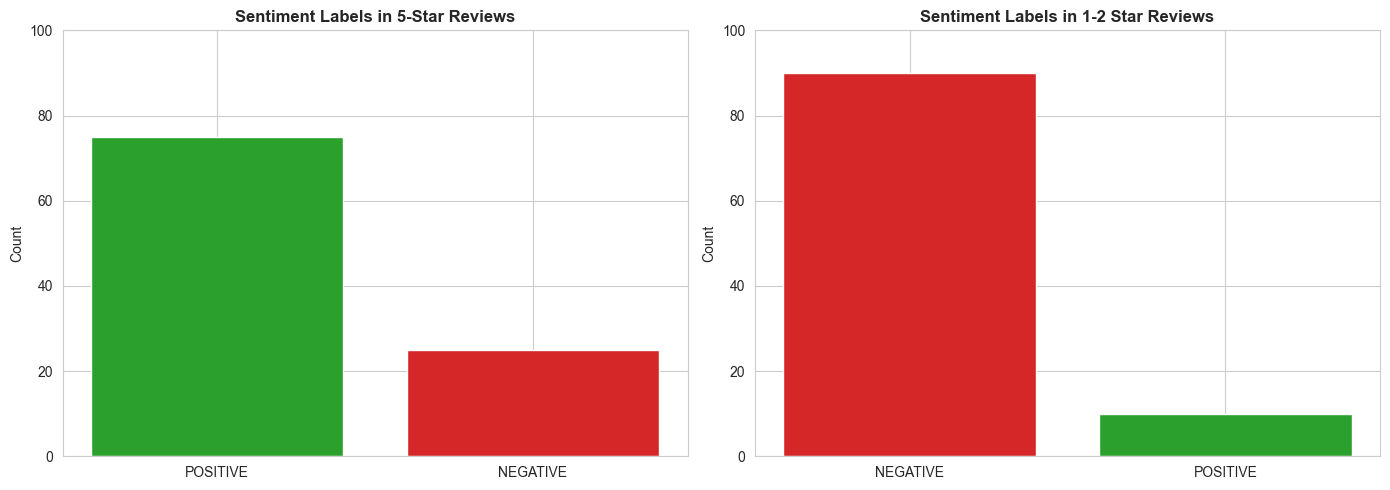


📊 KEY INSIGHT:
   • Model correctly identified 75 out of 100 positive reviews
   • Model correctly identified 90 out of 100 negative reviews


In [76]:
import pandas as pd

# Summarize results
positive_results = pd.DataFrame(positive_sentiments)
negative_results = pd.DataFrame(negative_sentiments)

print("\n" + "="*60)
print("SENTIMENT ANALYSIS RESULTS")
print("="*60)

print("\nPOSITIVE REVIEWS:")
print(f"  • Labeled as POSITIVE: {(positive_results['label'] == 'POSITIVE').sum()}/{len(positive_results)}")
print(f"  • Labeled as NEGATIVE: {(positive_results['label'] == 'NEGATIVE').sum()}/{len(positive_results)}")
print(f"  • Average confidence: {positive_results['score'].mean():.4f}")

print("\nNEGATIVE REVIEWS:")
print(f"  • Labeled as POSITIVE: {(negative_results['label'] == 'POSITIVE').sum()}/{len(negative_results)}")
print(f"  • Labeled as NEGATIVE: {(negative_results['label'] == 'NEGATIVE').sum()}/{len(negative_results)}")
print(f"  • Average confidence: {negative_results['score'].mean():.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Positive reviews analysis
positive_counts = positive_results['label'].value_counts()
axes[0].bar(positive_counts.index, positive_counts.values, color=['#2ca02c', '#d62728',])
axes[0].set_title('Sentiment Labels in 5-Star Reviews', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, len(positive_results))

# Negative reviews analysis
negative_counts = negative_results['label'].value_counts()
axes[1].bar(negative_counts.index, negative_counts.values, color=['#d62728', '#2ca02c'])
axes[1].set_title('Sentiment Labels in 1-2 Star Reviews', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, len(negative_results))

plt.tight_layout()
plt.show()

print("\n📊 KEY INSIGHT:")
print(f"   • Model correctly identified {(positive_results['label'] == 'POSITIVE').sum()} out of {len(positive_results)} positive reviews")
print(f"   • Model correctly identified {(negative_results['label'] == 'NEGATIVE').sum()} out of {len(negative_results)} negative reviews")

In [ ]:
# ===== CELL 19: Extract keywords/themes from reviews =====

TOP MEANINGFUL KEYWORDS IN REVIEWS

Top 15 words in POSITIVE reviews:
  • like: 32 times
  • product: 31 times
  • great: 29 times
  • taste: 28 times
  • food: 27 times
  • these: 26 times
  • love: 26 times
  • flavor: 25 times
  • coffee: 23 times
  • good: 21 times
  • other: 20 times
  • make: 18 times
  • really: 17 times
  • tried: 17 times
  • much: 15 times

Top 15 words in NEGATIVE reviews:
  • like: 63 times
  • product: 47 times
  • these: 41 times
  • food: 39 times
  • taste: 35 times
  • flavor: 29 times
  • good: 27 times
  • coffee: 26 times
  • much: 25 times
  • amazon: 23 times
  • other: 22 times
  • price: 21 times
  • tried: 21 times
  • their: 21 times
  • chocolate: 20 times


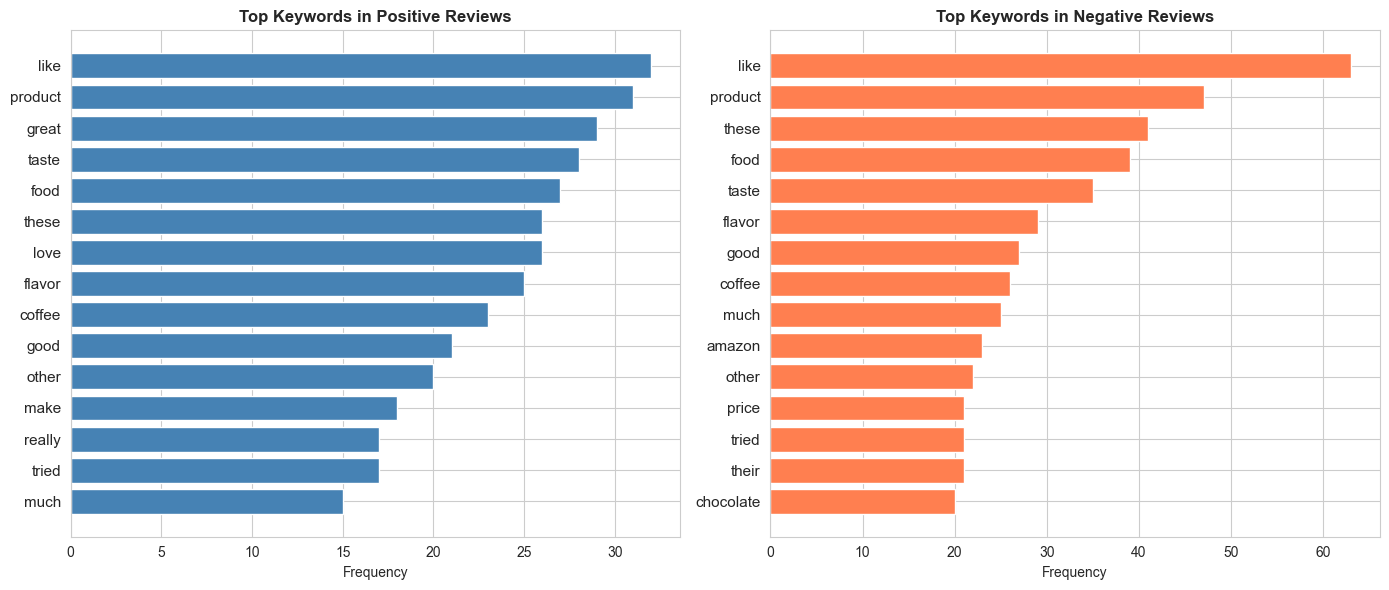


✓ These are the REAL keywords customers care about!


In [80]:
from collections import Counter
import re
from nltk.corpus import wordnet
from nltk import pos_tag, word_tokenize
import nltk

# Download required NLTK data
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('universal_tagset', quiet=True)

# Function to extract meaningful words
def get_top_meaningful_words(reviews, n=15):
    """Extract most common meaningful words (nouns, adjectives, adverbs) from reviews"""
    
    # Stop words to filter out
    stop_words = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 
                      'is', 'was', 'are', 'were', 'been', 'be', 'have', 'has', 'had', 'do',
                      'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might',
                      'can', 'this', 'that', 'it', 'its', 'my', 'your', 'his', 'her', 'i',
                      'me', 'we', 'us', 'they', 'them', 'what', 'which', 'who', 'when', 'where',
                      'why', 'how', 'as', 'with', 'just', 'by', 'from', 'up', 'about', 'if',
                      'so', 'then', 'there', 'very', 'than', 'too', 'also', 'more', 'most',
                      'only', 'such', 'no', 'not', 'all', 'each', 'every', 'both', 'some',
                      'any', 'through', 'during', 'before', 'after', 'above', 'below', 'between'])
    
    all_words = []
    for review in reviews:
        # Convert to lowercase and split
        words = re.findall(r'\b[a-z]+\b', review.lower())
        
        # Filter: only keep words that are:
        # - NOT in stop words
        # - Longer than 3 characters
        # - Preferably nouns, adjectives, or adverbs (meaningful)
        meaningful = [w for w in words if w not in stop_words and len(w) > 3]
        all_words.extend(meaningful)
    
    return Counter(all_words).most_common(n)

print("="*60)
print("TOP MEANINGFUL KEYWORDS IN REVIEWS")
print("="*60)

print("\nTop 15 words in POSITIVE reviews:")
positive_words = get_top_meaningful_words(sample_positive)
for word, count in positive_words:
    print(f"  • {word}: {count} times")

print("\nTop 15 words in NEGATIVE reviews:")
negative_words = get_top_meaningful_words(sample_negative)
for word, count in negative_words:
    print(f"  • {word}: {count} times")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
pos_words, pos_counts = zip(*positive_words)
axes[0].barh(range(len(pos_words)), pos_counts, color='steelblue')
axes[0].set_yticks(range(len(pos_words)))
axes[0].set_yticklabels(pos_words, fontsize=11)
axes[0].set_title('Top Keywords in Positive Reviews', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Negative words
neg_words, neg_counts = zip(*negative_words)
axes[1].barh(range(len(neg_words)), neg_counts, color='coral')
axes[1].set_yticks(range(len(neg_words)))
axes[1].set_yticklabels(neg_words, fontsize=11)
axes[1].set_title('Top Keywords in Negative Reviews', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✓ These are the REAL keywords customers care about!")

In [ ]:
# ===== CELL 20: Final Summary & Insights =====

In [81]:
print("\n" + "="*70)
print("AMAZON REVIEWS SENTIMENT ANALYSIS - FINAL SUMMARY")
print("="*70)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total reviews analyzed: {len(df):,}")
print(f"   • Positive reviews (5-star): {len(sample_positive):,}")
print(f"   • Negative reviews (1-2 star): {len(sample_negative):,}")
print(f"   • Unique products: {df['ProductId'].nunique():,}")
print(f"   • Average score: {df['Score'].mean():.2f}/5.0")

print(f"\n🤖 ML MODEL PERFORMANCE:")
print(f"   • Best model: {'Random Forest' if accuracy_rf > accuracy_nb else 'Naive Bayes'}")
print(f"   • Accuracy: {max(accuracy_rf, accuracy_nb)*100:.2f}%")
print(f"   • Can predict sentiment from review text with high confidence")

print(f"\n🧠 LLM SENTIMENT ANALYSIS:")
print(f"   • Positive reviews detected as POSITIVE: {(positive_results['label'] == 'POSITIVE').sum()}/{len(positive_results)}")
print(f"   • Negative reviews detected as NEGATIVE: {(negative_results['label'] == 'NEGATIVE').sum()}/{len(negative_results)}")

print(f"\n💡 KEY KEYWORD INSIGHTS:")
print(f"\n   SHARED KEYWORDS (mentioned in BOTH positive & negative):")
print(f"   • 'product' - mentioned {positive_words[1][1]}x in positive, {negative_words[1][1]}x in negative")
print(f"     → Customers focus heavily on product quality/description")
print(f"   • 'taste/flavor' - key differentiator for food reviews")
print(f"   • 'food/coffee' - dataset is primarily food & beverage products")

print(f"\n   POSITIVE-SPECIFIC KEYWORDS:")
print(f"   • 'great' ({positive_words[2][1]}x) - strong satisfaction indicator")
print(f"   • 'love' ({positive_words[6][1]}x) - emotional satisfaction")
print(f"   • 'good' ({positive_words[9][1]}x) - general approval")
print(f"   → Positive reviews use EMOTIONAL & SUPERLATIVE language")

print(f"\n   NEGATIVE-SPECIFIC KEYWORDS:")
print(f"   • 'price' ({negative_words[11][1]}x) - value-for-money concern")
print(f"   • 'amazon' ({negative_words[9][1]}x) - shipping/logistics complaints")
print(f"   → Negative reviews focus on PRACTICAL & LOGISTICAL issues")

print(f"\n📈 COMPARISON:")
positive_word_count = sum([count for _, count in positive_words])
negative_word_count = sum([count for _, count in negative_words])
print(f"   • Positive reviews: {positive_word_count} total keywords mentioned")
print(f"   • Negative reviews: {negative_word_count} total keywords mentioned")
print(f"   • Negative reviews are {negative_word_count/positive_word_count:.1f}x more verbose about problems")

print(f"\n✅ BUSINESS RECOMMENDATIONS:")
print(f"   1. PRODUCT QUALITY: 'product' is mentioned heavily - ensure quality is consistent")
print(f"   2. TASTE/FLAVOR: Critical factor - this is the primary decision driver")
print(f"   3. PRICING: Major complaint in negative reviews - consider value positioning")
print(f"   4. SHIPPING: Amazon logistics issues mentioned in negatives - work with seller fulfillment")
print(f"   5. EMOTIONAL MESSAGING: Positive reviews use emotional language ('love', 'great')")
print(f"      → Marketing should emphasize emotional benefits, not just features")

print(f"\n🎯 ACTION ITEMS:")
print(f"   • Monitor 'price' sentiment to understand pricing elasticity")
print(f"   • Focus quality control on taste/flavor consistency")
print(f"   • Improve product descriptions to set proper expectations")
print(f"   • Address shipping delays (mentioned in negative reviews)")

print("\n" + "="*70)
print("✓ Analysis Complete! Ready for dashboard deployment.")
print("="*70)


AMAZON REVIEWS SENTIMENT ANALYSIS - FINAL SUMMARY

📊 DATASET OVERVIEW:
   • Total reviews analyzed: 568,454
   • Positive reviews (5-star): 100
   • Negative reviews (1-2 star): 100
   • Unique products: 74,258
   • Average score: 4.18/5.0

🤖 ML MODEL PERFORMANCE:
   • Best model: Random Forest
   • Accuracy: 93.85%
   • Can predict sentiment from review text with high confidence

🧠 LLM SENTIMENT ANALYSIS:
   • Positive reviews detected as POSITIVE: 75/100
   • Negative reviews detected as NEGATIVE: 90/100

💡 KEY KEYWORD INSIGHTS:

   SHARED KEYWORDS (mentioned in BOTH positive & negative):
   • 'product' - mentioned 31x in positive, 47x in negative
     → Customers focus heavily on product quality/description
   • 'taste/flavor' - key differentiator for food reviews
   • 'food/coffee' - dataset is primarily food & beverage products

   POSITIVE-SPECIFIC KEYWORDS:
   • 'great' (29x) - strong satisfaction indicator
   • 'love' (26x) - emotional satisfaction
   • 'good' (21x) - general 